In [1]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib, pickle
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, ScalarFormatter, NullFormatter
plt.style.use('dissertation.mplstyle')
from IPython.display import clear_output

from python import forces, integrators, random_matrix, simulate, densities, plotters
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters);

---

#### Quick look at MALA.

In this version Euler-Maruyama is being used as the proposal. Eigenvalues cross very frequently for $dt > 1/N^2$, so it's likely $dt$ will need to scale $\sim \mathcal{O}(N^2)$ for reasonable results.

- Fix $N \in \{30, 70, 100\}$.
- For each $N$, try $dt \in \{\mathcal{O}(1)$, $~1/N$, $~1/N^2\}$.

Expect heavy rejects for $dt \neq \frac{1}{N^2}$. 

In [ ]:
N = 30;
dt_str = ["1/N", "1/NrootN", "1/N^7/4", "1/N^2"]
dt_range = [1/N, 1/(N**(3/2)), 1/(N**(7/4)), 1/(N**2)]
beta = 2.0; T = 5.0; M = 50; potential_name = "quartic"

config = {"track_accepts": True, "burn_in": 0}
new_obs_results = {}

for dt, dt_name in zip(dt_range, dt_str):
    burn_steps = int(3.0/dt); total_steps = int(T/dt);
    config["burn_in"] = burn_steps
    init = random_matrix.init_gue_eigenvalues(M, N)
    
    mala_pipe = simulate.make_mala_pipeline(N, dt, potential_name, beta)
    traj = simulate.simulate_dbm(init, total_steps, mala_pipe)
    all_info = simulate.analyse_trajectory(traj, total_steps, **config)

    new_obs_results[(dt_name)] = all_info

In [ ]:
dt_str_list = ["1/N", "1/NrootN", "1/N^7/4", "1/N^2"]
fig, ax = plt.subplots(figsize = (4, 2.3))

acceptances = [new_obs_results[(dt_str)]["accepts"].mean() for dt_str in dt_str_list]
cross_rejects = [new_obs_results[(dt_str)]["cross_rejects"].mean() for dt_str in dt_str_list]
other_rejects = [1 - acceptances[j] - cross_rejects[j] for j in range(len(acceptances))]

dt_str_list = [r"$1/N$", r"$1/N\sqrt{N}$", "$1/N^{7/4}$", "$1/N^2$"]
p1 = ax.bar(dt_str_list, acceptances, label = "Acceptances", color = '#2ca02c', edgecolor = 'white', width = 0.3)
p2 = ax.bar(dt_str_list, cross_rejects, bottom = acceptances, label = 'Rejects (Crossing)', color = '#d62728', edgecolor = 'white', width = 0.3)
p3 = ax.bar(dt_str_list, other_rejects, bottom = np.array(acceptances) + np.array(cross_rejects), label = 'Rejects (Other)', color = '#ff7f0e', edgecolor = 'white', width = 0.3)

ax.grid(False)
ax.set_ylim(-0.05, 1.1)

ax.set_ylabel("Percentage")
ax.set_xlabel("Step Size $\Delta t$")
ax.set_title(f"Dimension N = {N}")
ax.set_yticks([0, 0.5, 1])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig(f"figures/mala-cross-rejects-N{N}.pdf", format = "pdf", dpi = 120)

plt.show()

---
---
---

Adapative dt starts here - for MAIMLA dramatically lower number of steps.

---

In [2]:
def get_saved_init(M, N, potential_name):
    filename = f"data/inits/{potential_name}/M{M}-N{N}.pkl"
    with open(filename, "rb") as f:
        init = pickle.load(f)

    return init

In [ ]:
M = 100; beta = 2.0; pot_name = "quadratic";
total_steps = 50000; target = 0.7;
N_range = np.logspace(np.log10(30.5), np.log10(300.5), 8, dtype = int)
method = "hmc"

print(rf"For $N$ range {N_range}.")

last_accepts = np.zeros_like(N_range, dtype = float)
last_dts = np.zeros_like(N_range, dtype = float)
acc_histories = np.zeros_like(N_range, dtype = np.ndarray)
dt_histories = np.zeros_like(N_range, dtype = np.ndarray)

for j, N in enumerate(N_range):
    print(f"({j+1} of {len(N_range)}) Running for N = {N}.")
    if (N <= 150):
        total_steps = 50000
    elif (N <= 200):
        total_steps = 100000
    else:
        total_steps = 350000
    
    print(f"N{N} Total of {total_steps} steps.")
    init = get_saved_init(M, N, pot_name)
    dt_init = 1/(N) # Start near best guess..

    burn_steps = 0 # Since now running from equilibrium.
    accept_history, dt_history = simulate.target_dt(method, init, burn_steps, total_steps, pot_name, beta, dt_init, target)
    acc_histories[j] = accept_history; dt_histories[j] = dt_history
    
    last_accepts[j] = accept_history[-50:].mean()
    last_dts[j] = dt_history[-50:].mean()

In [ ]:
# Quick check on last accepts.
print(f"Accepts ", last_accepts)
print(last_dts)

fig, ax = plt.subplots()
ax.loglog(N_range, last_dts, label = "final dt", marker = 'o')

log_N = np.log10(N_range); log_dt = np.log10(last_dts);
slope, intercept = np.polyfit(log_N, log_dt, 1)
ax.plot(N_range, 10**(intercept)*N_range**slope, linestyle = "--", alpha = 0.5, label = f"slope {slope:.2f}")
ax.set_title(method.upper())

ax.legend()
plt.show()

In [ ]:
# Trace plots for these Ns.
for j, N in enumerate(N_range):
    fig, axes = plt.subplots(1, 2, figsize = (7, 2.25))
    axes[0].plot(acc_histories[j])
    axes[1].plot(dt_histories[j])

    ax1, ax2 = axes
    ax1.set_title(f"Acceptance Rate ({N})", fontsize = 14)
    ax2.set_title("Step Size", fontsize = 14)

    # plt.savefig("example-adapative-trace.pdf", format = "pdf", dpi = 120)
    plt.show()

In [ ]:
# Save the results.
import pickle

data = {}
for j, N in enumerate(N_range):
    key = (N, method) # (N, "hmc") for instance.

    data[key] = {
        "N": N, "M": M, "pot_name": pot_name,
        "burn_steps": int(0.5/(1/N)), "total_steps": total_steps,
        "num_last_avg": 50, # Hard coded in loop.
        "last_accepts": last_accepts[j], "last_dts": last_dts[j],
        "all_accepts": acc_histories[j], "all_dts": dt_histories[j]
    }

filename = f"data/adaptive_dt/{pot_name}/target{target}-{method}-N{','.join(map(str, N_range))}.pkl"
with open(filename, 'wb') as f:
    pickle.dump(data, f)

print(f"Data saved to {filename}.")

---
---
---
---
---
---

Reload and look at all results together.

---

## Needs a revamp now that we are looking at 0.7 and 0.1 too.

In [3]:
N_range_main = np.logspace(np.log10(30.5), np.log10(500.5), 10, dtype = int)
N_str_main = f"N{','.join(map(str, N_range_main))}"

N_range = np.logspace(np.log10(30.5), np.log10(300.5), 8, dtype = int)
N_str = f"N{','.join(map(str, N_range))}"

saved_methods_main = ["mala", "hmc", "maimla", "maila"]

quadratic_03_paths = [f"data/adaptive_dt/quadratic/quadratic-target0.3-{method}-{N_str_main}.pkl" for method in saved_methods_main]
# quadratic_06_paths = [f"data/adaptive_dt/quadratic/quadratic-target0.6-{method}-{N_str}.pkl" for method in ["mala"]]
# quartic_03_paths = [f"data/adaptive_dt/quartic/quartic-target0.3-{method}-{N_str}.pkl" for method in ["mala"]]
# quartic_06_paths = [f"data/adaptive_dt/quartic/quartic-target0.6-{method}-{N_str}.pkl" for method in ["mala"]]

def combine_dicts(file_paths):
    data = {}
    for path in file_paths:
        with open(path, "rb") as file:
            new_dict = pickle.load(file)
            data.update(new_dict)

    return data

quadratic_03_dict = combine_dicts(quadratic_03_paths)
# quadratic_06_dict = combine_dicts(quadratic_06_paths) # Change to 06
# quartic_03_dict = combine_dicts(quartic_03_paths)
# quartic_06_dict = combine_dicts(quartic_03_paths)

quadratic_03_dict.keys()

dict_keys([(np.int64(30), 'mala'), (np.int64(41), 'mala'), (np.int64(56), 'mala'), (np.int64(77), 'mala'), (np.int64(105), 'mala'), (np.int64(144), 'mala'), (np.int64(196), 'mala'), (np.int64(268), 'mala'), (np.int64(366), 'mala'), (np.int64(500), 'mala'), (np.int64(30), 'hmc'), (np.int64(41), 'hmc'), (np.int64(56), 'hmc'), (np.int64(77), 'hmc'), (np.int64(105), 'hmc'), (np.int64(144), 'hmc'), (np.int64(196), 'hmc'), (np.int64(268), 'hmc'), (np.int64(366), 'hmc'), (np.int64(500), 'hmc'), (np.int32(30), 'maimla'), (np.int32(41), 'maimla'), (np.int32(56), 'maimla'), (np.int32(77), 'maimla'), (np.int32(105), 'maimla'), (np.int32(144), 'maimla'), (np.int32(196), 'maimla'), (np.int32(268), 'maimla'), (np.int32(366), 'maimla'), (np.int32(500), 'maimla'), (np.int32(30), 'maila'), (np.int32(41), 'maila'), (np.int32(56), 'maila'), (np.int32(77), 'maila'), (np.int32(105), 'maila'), (np.int32(144), 'maila'), (np.int32(196), 'maila'), (np.int32(268), 'maila'), (np.int32(366), 'maila'), (np.int32(5

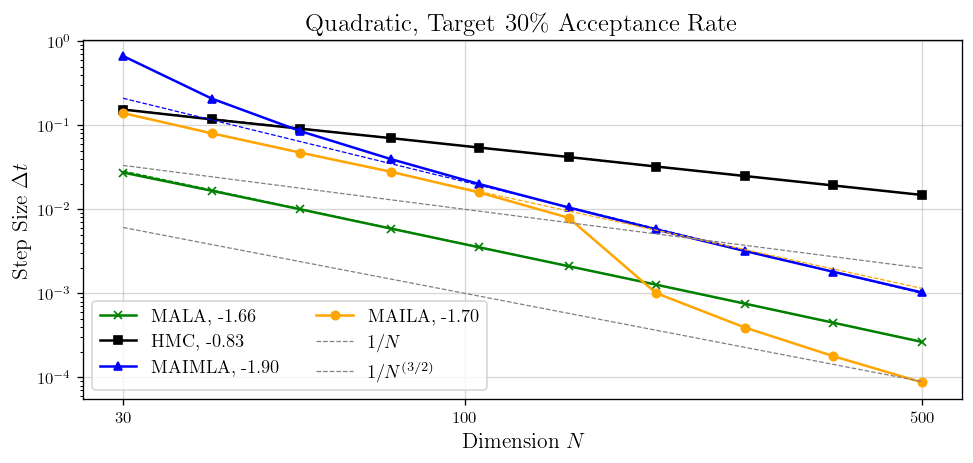

In [ ]:
fig, ax = plt.subplots(figsize = (8, 3.75))
colours = {"mala": "green", "maimla": "blue", "maila": "orange", "hmc": "black"}
markers = {"mala": "x", "maimla": "^", "maila": "o", "hmc": "s"}
quad_best_fits = {}

for method in saved_methods_main:
    N_scheme = N_range_main # 10 Ns between 30 and 500, evenly logspaced.
    last_dts = np.zeros_like(N_scheme, dtype = "float")

    for j, N in enumerate(N_scheme):
        last_dts[j] = quadratic_03_dict[(N, method)]["last_dts"]

    # Log and find slope.
    if (method != "maila"):
        log_N = np.log10(N_scheme[4:]); log_dts = np.log10(last_dts[4:])
    else:
        log_N = np.log10(N_scheme[0:6]); log_dts = np.log10(last_dts[0:6])

    slope, intercept = np.polyfit(log_N, log_dts, 1)
    quad_best_fits[(method, 0.3)] = (slope, intercept)
    
    colour = colours[method]
    marker = markers[method]
    ax.loglog(N_scheme, last_dts, label=f"{method.upper()}, {slope:.2f}", marker = marker, markersize=5, lw=1.5, color=colour)
    ax.plot(N_scheme, 10**(intercept)*N_scheme**slope, ls="--", lw=0.75, color=colour)

# 
test_range = N_range_main
ax.plot(test_range, 1/(test_range), label=r"$1/N$", color="grey", lw=0.75, ls="--")
ax.plot(test_range, 1/(test_range**(3/2)), label=r"$1/N^{(3/2)}$", color="grey", lw=0.75, ls="--")
ax.set_xlabel(r"Dimension $N$", fontsize=13)
ax.set_ylabel(r"Step Size $\Delta t$", fontsize = 13)

ax.set_title("Quadratic, Target 30\% Acceptance Rate", fontsize = 15)
ax.legend(fontsize = 11, ncols = 2, loc = "lower left")

xticks = [30, 100, 500]
ax.xaxis.set_major_locator(FixedLocator(xticks))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_locator(FixedLocator([]))   # kill default log minor ticks
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xticks(xticks)
ax.set_xticklabels([str(t) for t in xticks])


plt.show()    

---

In [12]:
# MAILA extrapolated dts.
slope, intercept = quad_best_fits[("maila", 0.3)]

test_ns = N_range_main
predicted_dts = 10**intercept*test_ns**slope

for N, dt in zip(test_ns, predicted_dts):
    print(f"N = {N}: predicted dt = {dt:.4f}")

N = 30: predicted dt = 0.1381
N = 41: predicted dt = 0.0811
N = 56: predicted dt = 0.0477
N = 77: predicted dt = 0.0277
N = 105: predicted dt = 0.0164
N = 144: predicted dt = 0.0096
N = 196: predicted dt = 0.0056
N = 268: predicted dt = 0.0033
N = 366: predicted dt = 0.0020
N = 500: predicted dt = 0.0011


---
---
---
---
---
---
---
---
---
---
---
---
---
---
---

To use for older data.

In [ ]:
hmc_paths = [f"data/adaptive_dt/hmc-N{N_range}.pkl" for N_range in ["50,70,100", "150"]]
mala_paths = [f"data/adaptive_dt/mala-N{N_range}.pkl" for N_range in ["50,70,100", "150,200"]]
maimla_paths = [f"data/adaptive_dt/maimla-N{N_range}.pkl" for N_range in ["50,70,100", "150,200"]]

maimla_paths_target03 = [f"data/adaptive_dt/target0.3-maimla-N{N_range}.pkl" for N_range in 
                         ["50,70,100,150,200", "250,300,350,400", "450,500,550,600"]]
mala_paths_target03 = [f"data/adaptive_dt/target0.3-mala-N{N_range}.pkl" for N_range in 
                       ["50,70,100,150,200", "250,300", "450,500,550,600", "800,1000"]]
maila_paths_target03 = [f"data/adaptive_dt/target0.3-maila-N{N_range}.pkl" for N_range in 
                       ["50,70,100", "150,200", "250,300"]]
hmc_paths_target03 = [f"data/adaptive_dt/target0.3-hmc-N{N_range}.pkl" for N_range in 
                       ["50,70,100,150", "200", "250"]]


def combine_dicts(file_paths):
    data = {}
    for path in file_paths:
        with open(path, "rb") as file:
            new_dict = pickle.load(file)
            data.update(new_dict)

    return data 
        
hmc_data = combine_dicts(hmc_paths)
mala_data = combine_dicts(mala_paths)
maimla_data = combine_dicts(maimla_paths)

maimla_data_target03 = combine_dicts(maimla_paths_target03)
mala_data_target03 = combine_dicts(mala_paths_target03)
maila_data_target03 = combine_dicts(maila_paths_target03)
hmc_data_target03 = combine_dicts(hmc_paths_target03)

data_target06 = {**hmc_data, **mala_data, **maimla_data}
data_target03 = {**mala_data_target03, **maimla_data_target03, **maila_data_target03, **hmc_data_target03}
data_target06.keys(), data_target03.keys()

In [ ]:
methods = ["hmc", "mala", "maimla", "mala_target03", "maimla_target03", "maila_target03", "hmc_target03"]
colours = {"mala": "green", "maimla": "blue", "maila": "orange", "hmc": "black"}
best_fits = {}; scheme_dts = {}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 3))

for method in methods:
    scheme = method if ("target" not in method) else method.split("_")[0]
    data = data_target06 if ("target" not in method) else data_target03 
    target = 0.6 if ("target" not in method) else 0.3
    ax = ax1 if target == 0.3 else ax2

    N_scheme = [N for (N, sch) in data if sch == scheme]
    print(f"{scheme.upper()}: ({target})", N_scheme)

    if (scheme == "maila"):
        N_scheme = N_scheme[0:4]

    last_dts = np.zeros_like(N_scheme, dtype = float)
    for j, N in enumerate(N_scheme):
        last_dts[j] = data[(N, scheme)]["last_dts"]

    scheme_dts[(scheme, target)] = (N_scheme, last_dts)
    
    # Find slope and intercept in log space.    
    log_N = np.log10(N_scheme); log_dts = np.log10(last_dts);
    slope, intercept = np.polyfit(log_N, log_dts, 1)
    best_fits[(scheme, target)] = (slope, intercept)

    # Plotter!
    colour = colours[scheme]
    ax.loglog(N_scheme, last_dts, label = f"{scheme.upper()}: {slope:.2f}", marker = 'x', markersize = 5, lw = 1.5, color = colour)
    ax.plot(N_scheme, 10**(intercept)*N_scheme**slope, ls = "--", lw = 0.75, color = colour)

test_range = np.logspace(np.log10(50), np.log10(1000), 5)
for ax in [ax1, ax2]:
    ax.plot(test_range, [1/(2*N) for N in test_range], label = r"$1/2N$", color = "grey", lw = 0.75, ls = "--")
    ax.plot(test_range, [1/(N**2) for N in test_range], label = r"$1/N^2$", color = "grey", lw = 0.75, ls = "--")
    ax.set_xlabel(r"Dimension $\log N$", fontsize = 13)

ax1.legend(fontsize = 12, ncols = 2); ax2.legend(fontsize = 12, ncols = 2);
ax1.set_title("Acceptance Target 0.3", fontsize = 15); ax2.set_title("Acceptance Target 0.6", fontsize = 15)
ax1.set_ylabel(r"Step Size $\log \Delta t$", fontsize = 13)

# plt.savefig("adapative-dt-TEMP.pdf", format = "pdf", dpi = 120)
plt.show()
best_fits.keys(), scheme_dts.keys()

---

Extrapolate the fits and see for larger $N$, e.g. $N = 1000, 2000$.

In [ ]:
# Target acceptance 0.3.
large_N = 1000; M = 100; potential_type = "quartic"; beta = 2.0;
mala_slope, mala_c = best_fits[("mala", 0.3)]
maimla_slope, maimla_c = best_fits[("maimla", 0.3)]

mala_dt = 10**(mala_c)*large_N**(mala_slope)
maimla_dt = 10**(maimla_c)*large_N**(maimla_slope)
print(f"MALA {mala_dt}, MAIMLA {maimla_dt}, ratio {maimla_dt/mala_dt}.")

init = random_matrix.init_gue_eigenvalues(M, N)
print(f"Init finished.")

mala_pipe = simulate.make_mala_pipeline(N, mala_dt, potential_type, beta)
# maimla_pipe = simulate.make_maimla_pipeline(N, maimla_dt, potential_type, beta)

T = 0.25
total_steps = 1000 # Overwrite later.
mala_traj = simulate.simulate_dbm(init, total_steps, mala_pipe)
# maimla_traj = simulate.simulate_dbm(init, total_steps, maimla_pipe)

config = {"burn_in": 0, "track_accepts": True}
mala_info = simulate.analyse_trajectory(mala_traj, total_steps, **config)
# maimla_info = simulate.analyse_trajectory(maimla_traj, total_steps, **config)

print(mala_info["accepts"].mean())
#, mamla_info["accepts"].mean()

---
---
---

Compare MAIMLA vs MALA on the same plot, including for different target.

---

In [ ]:
N_range = [50, 70, 100, 150, 200] # For MALA and HMC
methods = ["mala", "maimla", "maimla_target03", "mala_target03"]

fig, ax = plt.subplots()

for j, method in enumerate(methods):
    dts = np.zeros_like(N_range, dtype = float)

    if ("target" in method):
        target = 0.3
        dict = data_target03
        method = method.split("_")[0]
    else:
        target = 0.6
        dict = data 
    for jj, N in enumerate(N_range):
        key = (N, method)
        # print(f"On key {key}.")
        dts[jj] = dict[key]["last_dts"]

    log_N = np.log10(N_range); log_dts = np.log10(dts);
    slope, intercept = np.polyfit(log_N, log_dts, 1)
    ax.loglog(N_range, dts, label = f"{method.upper()}, {target}, {slope:.2f}", marker = "o", lw = 1.5)

ax.plot(N_range, [1/(N) for N in N_range], linestyle = "--", alpha = 1, color = "gray", label = r"$1/N$")
ax.plot(N_range, [1/(4*N) for N in N_range], linestyle = "--", alpha = 1, color = "gray", label = r"$1/4N$")
# ax.plot(N_range, [1/(N**2) for N in N_range], linestyle = "--", alpha = 1, color = "gray", label = r"$1/N^2$")
ax.set_xlabel(r"log $N$")
ax.set_ylabel(r"log $\Delta t$")
ax.set_title("Adapative Step Size Tuning")

ax.legend(ncol = 2)
plt.show()


---
---
---
---
---

(Older) Using the linear fit see how they behave for larger $N$, e.g. $N = 300, 500$.

---

In [ ]:
# print(extrap_N_range[7])
# = 349.65, so index = 7.
N = 350; 
M = 10; beta = 2.0; T = 5.0; pot_name = "quartic";

for j, method in enumerate(methods):
    init = random_matrix.init_gue_eigenvalues(M, N)
    dt = extrapolated_dts[j][7]
    total_steps = int(T/dt)
    print(method, dt)

    if (method == "maimla"):
        pipe = simulate.get_pipeline(
            "imla", N = N, dt = dt, potential_type = pot_name, beta = beta,
            metropolise = True)
    else:
        pipe = simulate.get_pipeline(
            method, N = N, dt = dt, potential_type = pot_name, beta = beta)
    
    trajectory = simulate.simulate_dbm(init, total_steps, pipe)
    config = {"burn_in": int(2.0/dt), "track_accepts": True}
    info = simulate.analyse_trajectory(trajectory, total_steps, **config)

    fig, axes = plt.subplots(2, 1, figsize = (6, 5))
    ax, ax2 = axes
    plotters.plot_hist(ax, info["snapshots"], num_bins = 100, potential_name = pot_name)
    plotters.plot_accepts(ax2, info["accepts"])
    
    ax.grid(False)
    ax.set_title(method.upper())
    plt.show()

---
---
---
---
---

In [ ]:
from python.newton import solve_newton_single
from numba import njit
potential_ints = {"quadratic": 0, "quad-quartic": 1, "quartic": 2, "wishart-laguerre": 3}

In [ ]:
@njit
def temp_implicit_step(x, dt, potential_int, beta, 
                       max_newton_iters = 50, newton_tol = 1e-6, cg_tol = 1e-9):
    # ==========================================
    M, N = x.shape; next_x = np.zeros_like(x)
    noise_scale = np.sqrt(2*dt/(beta*N))
    c = 1

    newton_iters = np.zeros(M); mean_cg_iters = np.zeros(M, dtype = float); # Counters.
    coulomb = np.zeros(N); hess = np.zeros((N, N)); proposed_x = np.zeros(N) # All act as temp.
    log_energies = np.zeros(M)

    # Noise, included in the solve.
    noise = np.random.normal(0.0, 1.0, x.shape)
    z = x + noise_scale*noise 

    for m in range(M):
        current_x, trial_newton_iters, trial_avg_cg_iters = solve_newton_single(
            x[m], z[m], dt, potential_int, max_newton_iters, newton_tol, cg_tol,
            coulomb, hess, proposed_x
        )

        next_x[m] = current_x 
        newton_iters[m] = trial_newton_iters; mean_cg_iters[m] = trial_avg_cg_iters;

        # Edit: energies for this x, exp(-beta*N*H_N(x)).
        v = forces.evaluate_force(current_x, potential_int, 0, c)
        log_rep = forces.log_repulsion(current_x)
        ham = 0.5*np.sum(v) - np.sum(log_rep)
        log_energies[m] = -beta*N*ham

    return next_x, log_energies

In [ ]:
N = 50; dt = 0.1; beta = 2.0; T = 3.0;
M = 100; potential_name = "quadratic"; potential_int = potential_ints[potential_name]
total_steps = int(T/dt)
init = random_matrix.init_gue_eigenvalues(M, N)

traj = np.zeros((M, N, total_steps))
log_energies = np.zeros((M, total_steps))
traj[:, :, 0] = init

for step in range(1, total_steps):
    next_x, log_energy = temp_implicit_step(traj[:, :, step - 1], dt, potential_int, beta)
    traj[:, :, step] = next_x
    log_energies[:, step] = log_energy

In [ ]:
last = traj[:, :, -1]


In [ ]:
# Sanity histogram check.
fig, ax = plt.subplots()
plotters.plot_hist(ax, traj[:, :, -1].flatten(), num_bins = 500, potential_name = potential_name)
plt.show()

In [ ]:
for m in range(M):
    fig, ax = plt.subplots()
    ax.plot(np.array(range(1, total_steps)), log_energies[m, 1:], marker = 'x')

    plt.show()

---

In [ ]:
N = 300; dt = 1/N; beta = 2.0; T = 3.0;
M = 3; potential_name = "quartic"; potential_int = potential_ints[potential_name]
total_steps = int(T/dt)
init = random_matrix.init_gue_eigenvalues(M, N)

traj = np.zeros((M, N, total_steps))
log_energies = np.zeros((M, total_steps))
traj[:, :, 0] = init

for step in range(1, total_steps):
    next_x, log_energy = temp_implicit_step(traj[:, :, step - 1], dt, potential_int, beta)
    traj[:, :, step] = next_x
    log_energies[:, step] = log_energy

In [ ]:
for m in range(M):
    fig, ax = plt.subplots()
    ax.plot(np.array(range(1, total_steps)), log_energies[m, 1:], marker = 'x')

    plt.show()

---
---
---

- Run the implicit sampler for $N = 100$, change $\Delta t$ in logspace.
- Average the energies from the second half of the trajectory (set $T = 3.0$, say).
- Plot average energy vs $\Delta t$.

In [ ]:
N = 100; beta = 2.0; T = 3.0;
M = 3; potential_name = "quartic"; potential_int = potential_ints[potential_name]
init = random_matrix.init_gue_eigenvalues(M, N)

dt_range = np.logspace(0, -3, 10)
avg_energies = np.zeros_like(dt_range, dtype = float)

for j, dt in enumerate(dt_range):
    total_steps = int(T/dt)
    traj = np.zeros((M, N, total_steps))
    log_energies = np.zeros((M, total_steps))
    traj[:, :, 0] = init

    for step in range(1, total_steps):
        next_x, log_energy = temp_implicit_step(traj[:, :, step - 1], dt, potential_int, beta)
        traj[:, :, step] = next_x
        log_energies[:, step] = log_energy

    energy_plateau = 0
    for m in range(M):
        energy_plateau += np.mean(log_energies[:, (total_steps//2):])

    energy_plateau = energy_plateau/M 
    avg_energies[j] = np.abs(energy_plateau) # So now beta*N*H_N, not negative.
    print(f"Value {energy_plateau:.4f}.")

---
---
---